In [ ]:
# Install library
try:
    !python -m pip install -q -r requirements.txt
    print("Installation of dependencies completed successfully.")
except Exception as e:
    print(f"An error occurred while installing dependencies: {e}")

# import libraries
import re
import string
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline


Installation of dependencies completed successfully.


/workspaces/Sentiment-Free-Nutrient-Food/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Read Dataset
df = pd.read_csv('Dataset MBG.csv')
df.shape

(29965, 8)

## **Preprocessing Data**

In [25]:
# 1 - Data Cleaning
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # hapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # hapus hashtag
    text = re.sub(r'RT[\s]', '', text) # hapus RT
    text = re.sub(r"http\S+", '', text) # hapus link
    text = re.sub(r'[0-9]+', '', text) # hapus angka
    text = re.sub(r'[^\w\s]', '', text) # hapus karakter selain huruf dan angka
    text = text.lower() # mengkonversi ke huruf kecil
    text = re.sub(r'\s+', ' ', text) # hapus spasi ganda/multiple
    text = text.strip() # hapus spasi di awal dan akhir
    return text

# 2 - Normalize Data (Shortening Words)
kamus_df = pd.read_csv('Colloquial-indonesian-lexicon.csv')
kamus = dict(zip(kamus_df['slang'].astype(str).str.lower(), kamus_df['formal'].astype(str)))

def normalize_alay(text):
    """Normalize informal Indonesian words to formal ones"""
    words = text.split()
    normalized = []
    for word in words:
        # Check if word is in informal dictionary, replace if found
        normalized.append(kamus.get(word, word))
    return ' '.join(normalized)


# 3 - Remove Stopwords
# Load Indonesian stopwords
with open('Stopwords-indonesia.txt', 'r') as file:
    stopwords = set(file.read().split())

words_to_delete = [
    'makan', 'siang', 'gratis', 'prabowo', 'bangsa', 'kayak',
    'rakyat', 'masyarakat', 'presiden', 'program', 'nya', 'sih',
    'jokowi', 'pilih', 'mbak', 'pak', 'bu', 'mas', 'mbak', 'om', 'tante', 'kakak', 'adik',
    'kalian', 'kami', 'kamu', 'dia', 'mereka', 'program ', 'indonesia', 'sekolah', 'anak',
    'kalo', 'ya', 'lu', 'bikin', 'didik', 'loh'
]

# Tokenize and remove stopwords
def remove_stopwords(texts):
    tokens = texts.split()
    tokens = [word for word in tokens if word not in stopwords]  # remove stopwords
    tokens = [word for word in tokens if word not in words_to_delete]  # remove specific words
    return ' '.join(tokens)

In [27]:
# 4 - Stemming using sastrawi
stemmer = StemmerFactory().create_stemmer()

# 5 - Classify Text using Pre-Trained Model
pretrained_id = "mdhugol/indonesia-bert-sentiment-classification"
tokenizer = AutoTokenizer.from_pretrained(pretrained_id)
model = AutoModelForSequenceClassification.from_pretrained(pretrained_id)
pipeline_sentiment = pipeline("text-classification", model=model, tokenizer=tokenizer)

# sentiment label index
label_index = {'LABEL_0': 'positive', 'LABEL_1': 'neutral', 'LABEL_2': 'negative'}

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mdhugol/indonesia-bert-sentiment-classification
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [28]:
# 1 - Cleaning Data
df['text_cleaning'] = df['text'].apply(cleaningText)
# 2 - Normalized Texts
df['normalized_alay'] = df['text_cleaning'].apply(normalize_alay)
# 3 - Remove Stopwords
df['no_stopwords_text'] = df['normalized_alay'].apply(remove_stopwords)
# 4 - Stemming Process
df['stemmed_text'] = df['no_stopwords_text'].apply(stemmer.stem)



## **Data Labelling**

In [29]:
# Take sample data for labelling
train = df.sample(n=3000).copy()

# APPLY SENTIMENT analysis to the training set  - detect by tqdm
# text_clf = train['stemmed_text'].apply(pipeline_sentiment)

sentiment, score = [], []
for t in tqdm(train['stemmed_text']):
    result = pipeline_sentiment(t)
    sentiment.append(result[0]['label'])
    score.append(result[0]['score'])

sentiment_label = [label_index[label] for label in sentiment]

# Assign result
train['sentiment_label'], train['sentiment_score'] = sentiment_label, score

100%|██████████| 3000/3000 [05:54<00:00,  8.47it/s]


In [30]:
top_sentiment = train[train['sentiment_score']>=0.95][['text','stemmed_text','sentiment_label','sentiment_score']].copy()
top_sentiment['sentiment_label'].value_counts()

,count
sentiment_label,
negative,840
neutral,628
positive,236


In [36]:
# Check Positive Sentiment Sample
def check_sentiment_sample(label, count):
    d = top_sentiment[top_sentiment['sentiment_label'] == label].sample(count).loc[
        :,['text','stemmed_text','sentiment_label','sentiment_score']
    ]
    # .reset_index(drop=True)

    for i in range(count):
        display(d.index[i], d.iloc[i]['text'])
        display(d.iloc[i]['stemmed_text'])
        print(d.iloc[i]['sentiment_label'])
        print(d.iloc[i]['sentiment_score'])
        print()

check_sentiment_sample('negative', 3)
check_sentiment_sample('positive', 3)

np.int64(20815)

'@KompasTV Program MBG mana,cuma di kota2 besar doang'

'manacuma kota doang'

negative
0.9874825477600098



np.int64(28273)

...

positive
0.9891363382339478



np.int64(16355)

'Dukung program makan bergizi gratis #DukungMBG\n https://t.co/MZLX83lzKc'

'dukung gizi'

positive
0.9794393181800842



## **Visualization**

In [37]:
def plot_wordcloud(df, label, max_words=200, background_color='white', colormap='viridis'):
    texts = df[df['sentiment_label'] == label]['stemmed_text'].dropna().astype(str)
    if texts.empty:
        print(f"No records found for label '{label}'")
        return
    combined = " ".join(texts.tolist())
    wc = WordCloud(width=800, height=400,
                   background_color=background_color,
                   max_words=max_words,
                   colormap=colormap,
                   stopwords=set(STOPWORDS))
    wc.generate(combined)

    plt.figure(figsize=(15, 7.5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud - {label.capitalize()} Sentiment", fontsize=20)
    plt.show()

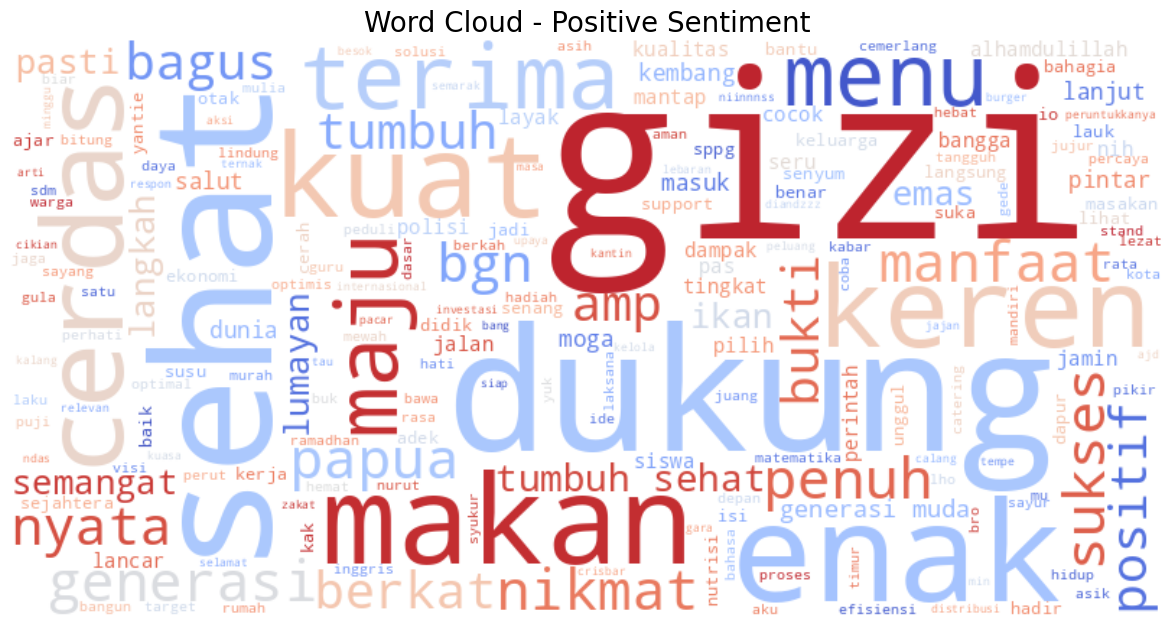

In [38]:
# POSITIVE
plot_wordcloud(top_sentiment, 'positive', colormap='coolwarm')

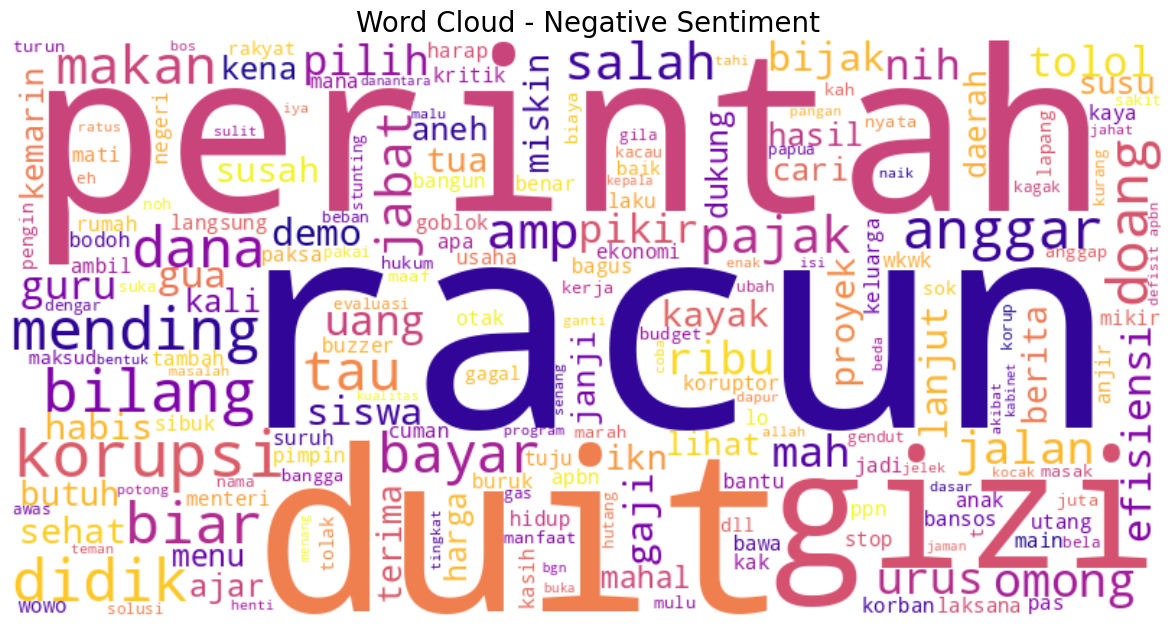

In [39]:
# NEGATIVE
plot_wordcloud(top_sentiment, 'negative', colormap='plasma')

In [43]:
# Plot by Frequencies
def top_words(df, label, n=20):
    """Plot the top n words for a given sentiment label (biggest frequency shown at top)."""
    texts = df.loc[df['sentiment_label'] == label, 'stemmed_text'].dropna().astype(str)
    if texts.empty:
        print(f"No records for label '{label}'")
        return

    all_words = " ".join(texts.tolist()).split()
    freq = pd.Series(all_words).value_counts().head(n).sort_values(ascending=True)

    # Custom color for plotting (AI-assisted)
    base = np.array([0.12, 0.47, 0.71])
    factors = np.linspace(0.35, 1.0, len(freq))  # light -> strong
    colors = [tuple(base * f + (1 - f)) for f in factors]  # blend toward white

    plt.figure(figsize=(12, 6))
    bars = plt.barh(freq.index, freq.values, color=colors)

    plt.xlabel("Frequency", fontsize=12)
    plt.ylabel("Words", fontsize=12)
    plt.title(f"Top {n} Words - {label.capitalize()} Sentiment", fontsize=14, fontweight="bold")

    # Value labels
    max_val = freq.max()
    for b in bars:
        w = b.get_width()
        plt.text(w + max_val * 0.01, b.get_y() + b.get_height()/2, f"{int(w)}",
                 va="center", fontsize=10)

    plt.grid(axis="x", linestyle="--", alpha=0.25)
    plt.tight_layout()
    plt.show()

## **Insights Gathered**

In [41]:
sentiment_counts = top_sentiment['sentiment_label'].value_counts()
total_sentiments = sentiment_counts.sum()
sentiment_percentages = (sentiment_counts / total_sentiments) * 100

print("Sentiment Distribution (Counts):")
print(sentiment_counts)
print("\nSentiment Distribution (Percentages):")
print(sentiment_percentages.round(2))

Sentiment Distribution (Counts):
sentiment_label
negative    840
neutral     628
positive    236
Name: count, dtype: int64

Sentiment Distribution (Percentages):
sentiment_label
negative    49.30
neutral     36.85
positive    13.85
Name: count, dtype: float64


### **Summary of Sentiment Distribution**

The analysis of the `top_sentiment` DataFrame, which includes tweets with a sentiment score confidence of 0.95 or higher, reveals the following distribution of public opinion regarding the 'Makan Siang Gratis' program:

*   **Negative Sentiment:** Constitutes the largest portion at **49.30%**. This indicates that nearly half of the high-confidence public discourse surrounding the program is critical or unfavorable.
*   **Neutral Sentiment:** Accounts for **36.85%** of the sentiments. A significant portion of the conversation is neither explicitly positive nor negative, suggesting a measured or objective tone, or perhaps a lack of strong opinion.
*   **Positive Sentiment:** Represents the smallest share at **13.85%**. This suggests that genuinely positive feedback or support for the program is relatively low among the high-confidence sentiments.

In conclusion, the overall sentiment towards the 'Makan Siang Gratis' program appears to be predominantly negative, with a substantial neutral component and a comparatively small positive reception among the analyzed high-confidence tweets.

=== NEGATIVE ===


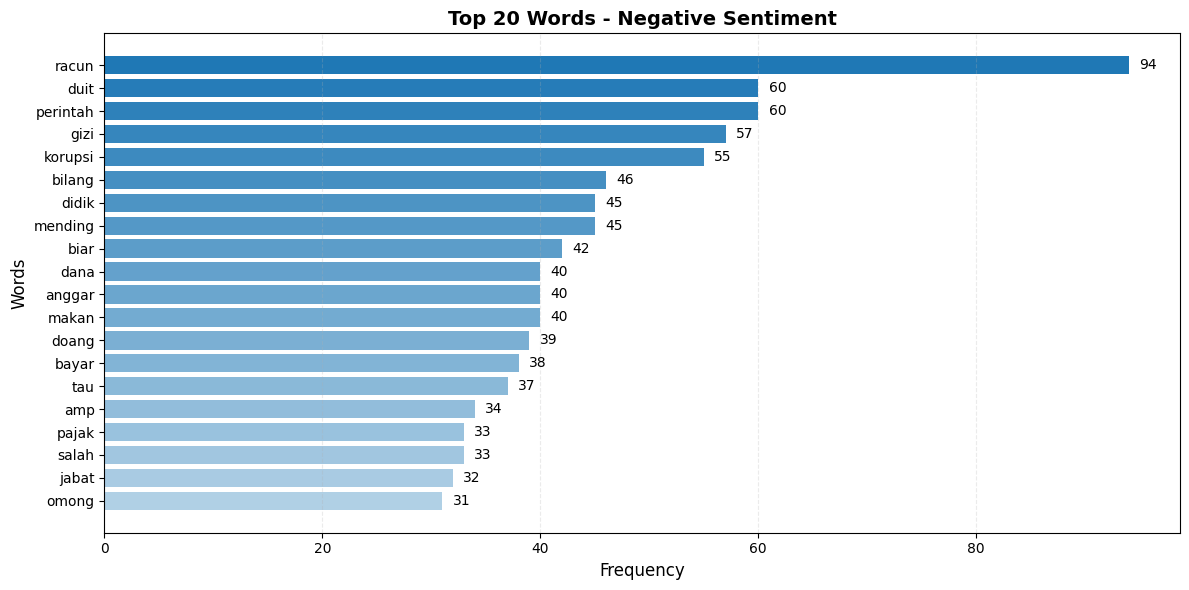

In [44]:
print("=== NEGATIVE ===")
top_words(top_sentiment, "negative", 20)

### **Analyzing Negative Sentiment Themes**

Based on the 'NEGATIVE' word cloud and the 'NEGATIVE' top words plot, we can identify the following key themes and criticisms regarding the 'Makan Siang Gratis' (Free Lunch) program:

**Findings:**
After reviewing both visualizations, i found that all of these keywords became the most critisized aspects in the MBG project by the Government:

*   Aspect related to **cost or funding** (e.g., 'dana', 'anggaran', 'duit', 'bayar')
*   Aspect related to **inefficiency or waste** (e.g., 'buang', 'rugi')
*   Aspect related to **quality, suitability or healthy** (e.g., 'racun','buruk', 'gizi')
*   Aspect related to **political or social issues** (e.g., 'pejabat', 'pajak', 'korupsi')
*   Aspect indicating **disagreement or opposition** (e.g., 'salah')

**Narrative Summary Example:**

"The negative sentiment surrounding the 'Makan Siang Gratis' program appears to be primarily driven by concerns about [**Theme 1, e.g., 'financial mismanagement'**] and [**Theme 2, e.g., 'the quality & healthy of the food'**]. Keywords such as 'anggaran', 'dana', and 'duit' frequently appear, suggesting public skepticism about the program's economic feasibility and potential for waste. Additionally, words like 'gizi', 'racun', and 'buruk' indicate that the nutritional value or overall quality of the food provided is a significant point of criticism. Some comments also touch upon the political motivations behind the program, with terms like 'korupsi' and 'jabat' as pejabat hinting at unfulfilled promises or electoral campaigning."

=== POSITIVE ===


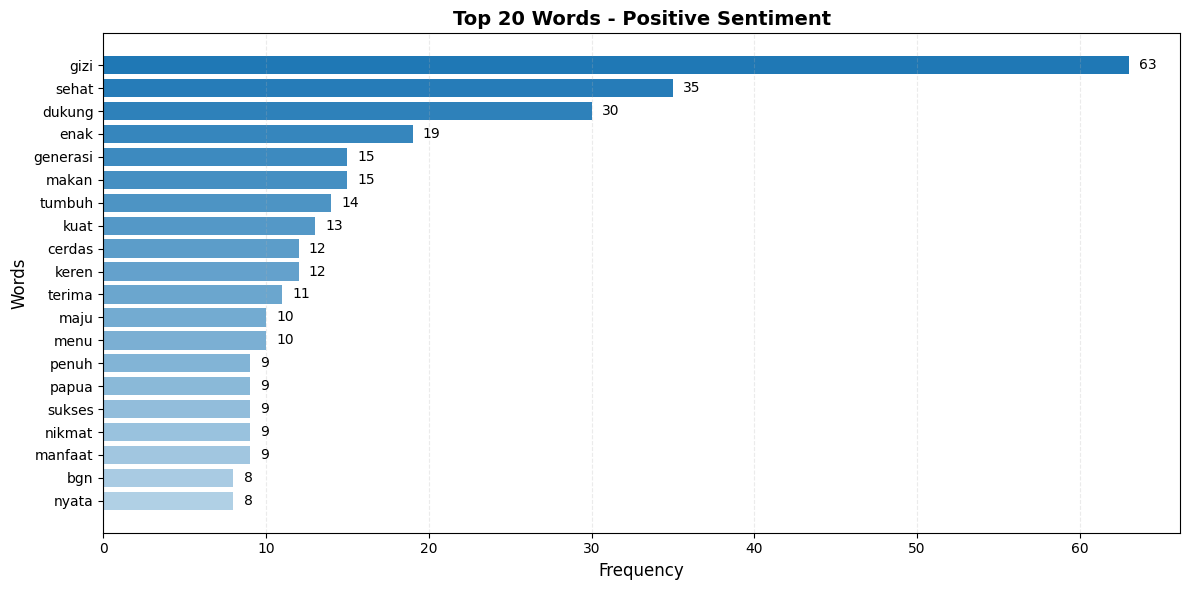

In [45]:
print("=== POSITIVE ===")
top_words(top_sentiment, "positive", 20)

## Analysis of Positive Sentiment Themes

Based on the 'POSITIVE' word cloud and top words plot, several key themes emerge regarding public sentiment towards the 'Makan Siang Gratis' (Free Lunch) program:

1.  **Direct Program Impact & Benefit:** Words like 'enak', 'manfaat', 'keren', 'cerdas' and 'sukses' strongly suggest that the public perceives the program as directly beneficial and helpful. This indicates that the core objective of the program, providing assistance, is being well-received.

2.  **Nutritional and Health Focus:** The presence of 'gizi', 'enak', 'nikmat', 'kuat' and 'sehat' highlights that the program is associated with improving health and nutritional intake, especially for 'generasi' which represents 'anak'. This implies that the health-related outcomes of the program are a significant factor in its positive reception.

3.  **Support and Approval:** Keywords like 'dukung' (support) and 'maju' (forward) show that there is a level of public backing for the program, and people believe in its potential to achieve its goals.

In summary, the positive sentiment primarily revolves around the program's perceived benefits in terms of direct aid, improved nutrition and health, and broad public support for its objectives and implementation. The public seems to appreciate the program's potential to address immediate needs and contribute to a healthier future, especially for the younger generation.